In [3]:
import os 
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
import cv2

In [17]:
def visualize_image(image):
    plt.figure(figsize=(7, 7))
    plt.axis("off")
    plt.imshow(image)

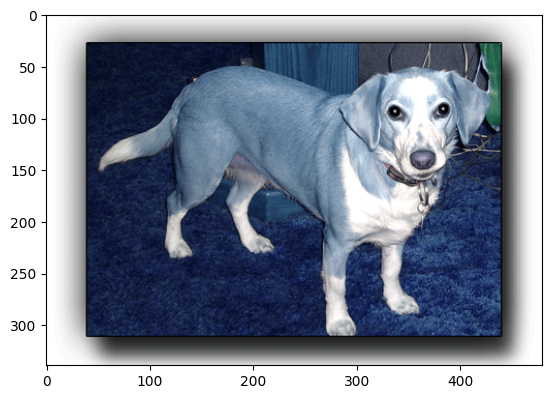

In [18]:
image = cv2.imread("../dataset/sample_images/dog_180.jpg")
plt.imshow(image) 

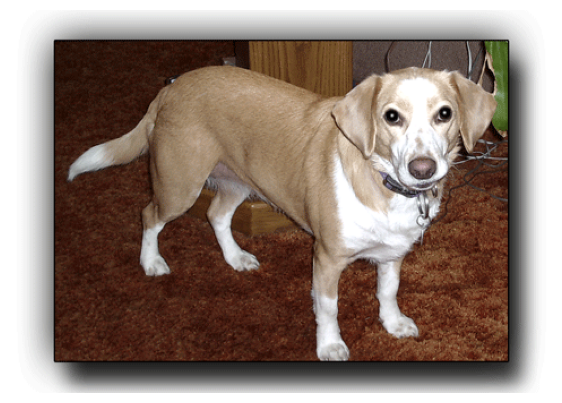

In [19]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
visualize_image(image)

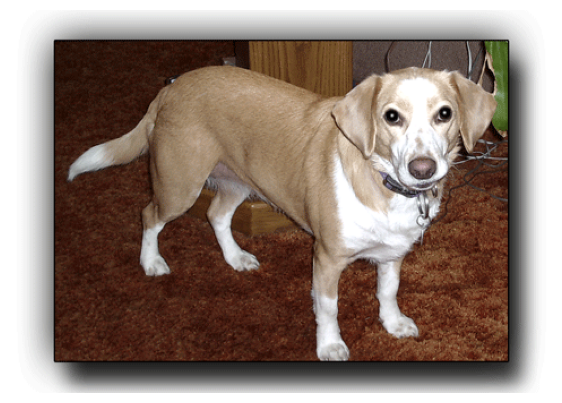

In [33]:
transform = A.HorizontalFlip(p=0.5)
random.seed(10)
augmented_image = transform(image=image)['image']
visualize_image(augmented_image)

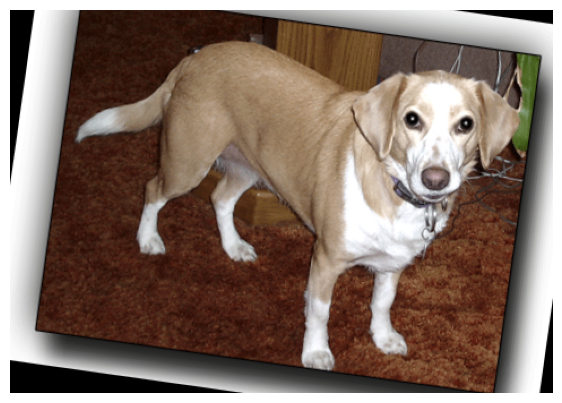

In [39]:
transform = A.ShiftScaleRotate(p=0.5)
random.seed(10)
augmented_image = transform(image=image)['image']
visualize_image(augmented_image)

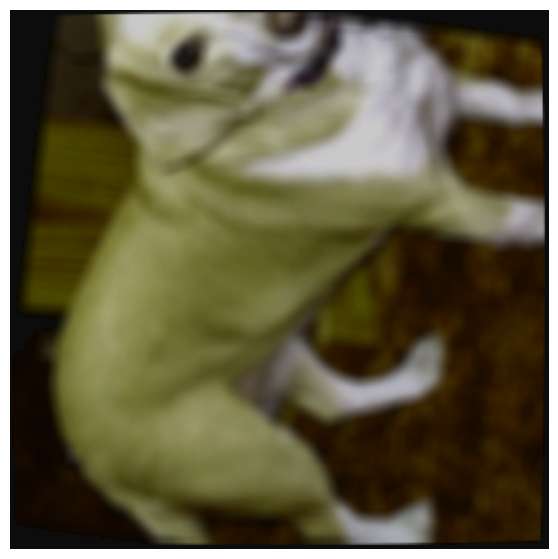

In [48]:
transform = A.Compose([
    A.CLAHE(),
    A.RandomCrop(width=256, height=256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.RandomRotate90(),
    A.Transpose(),
    A.ShiftScaleRotate(),
    A.Blur(),
    A.OpticalDistortion(),
    A.GridDistortion(),
    A.HueSaturationValue()
])

random.seed(10)
augmented_image = transform(image=image)['image']
visualize_image(augmented_image)

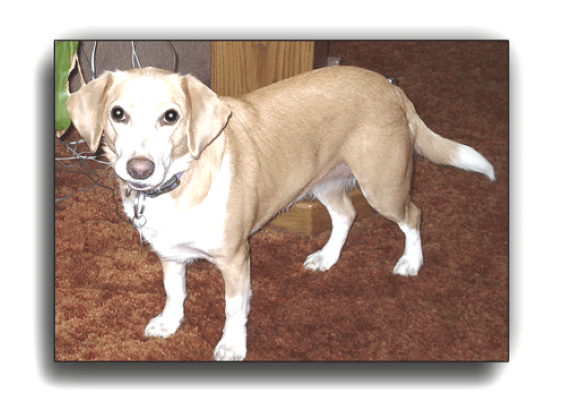

In [70]:
# 1. Define the pipeline
pipeline = A.Compose([
    A.HorizontalFlip(p=0.5), # 50% chance to flip
    A.RandomBrightnessContrast(p=0.8), # 80% chance to adjust brightness/contrast
    A.GaussianBlur(p=0.3), # 30% chance to blur
    A.GaussNoise(p=0.1)
])

# 2. Apply the pipeline
transformed_data = pipeline(image=image)
transformed_image = transformed_data['image']
visualize_image(transformed_image)

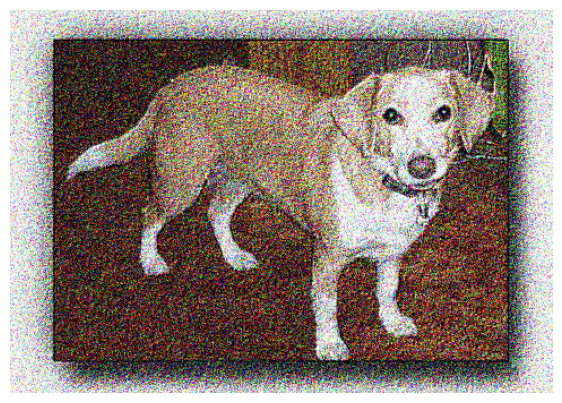

In [77]:
complex_pipeline = A.Compose([
    # --- Block 1: Basic Transform ---
    A.HorizontalFlip(p=0.5),
    A.GaussNoise(),
    # --- Block 2: Choose ONE of two sequences ---
    A.OneOf([
        A.Sequential([
            A.GaussianBlur(p=1.0),
            A.Sharpen(p=1.0),
        ], p=1.0),

        A.Emboss(p=1.0)

    ], p=0.8)
])

# Applying the complex pipeline:
transformed_data = complex_pipeline(image=image)
transformed_image = transformed_data['image']
visualize_image(transformed_image)

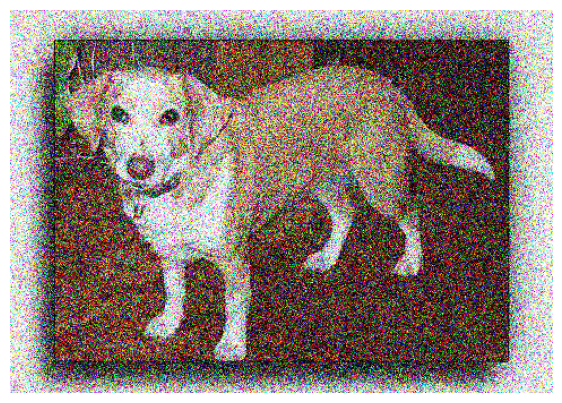

In [84]:
transform = A.Compose([
        A.RandomRotate90(),
        A.HorizontalFlip(),
        A.Transpose(),
        A.GaussNoise(),
        A.OneOf([
            A.MotionBlur(p=.2),
            A.MedianBlur(blur_limit=3, p=0.1),
            A.Blur(blur_limit=3, p=0.1),
        ], p=0.2),
        A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.2, rotate_limit=45, p=0.2),
        A.OneOf([
            A.OpticalDistortion(p=0.3),
            A.GridDistortion(p=.1),
        ], p=0.2),
        A.OneOf([
            A.CLAHE(clip_limit=2),
            A.RandomBrightnessContrast(),
        ], p=0.3),
        A.HueSaturationValue(p=0.3),
    ])
random.seed(42)
augmented_image = transform(image=image)['image']
visualize_image(augmented_image)

### More Transformations

```
    A.Rotate(limit=45, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.RandomGamma(p=0.5),
    A.Blur(blur_limit=3, p=0.3),
    A.MotionBlur(blur_limit=3, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.GaussNoise(var_limit=(10, 50), p=0.5),
    A.CLAHE(clip_limit=2.0, p=0.5),
    A.ColorJitter(p=0.5),
    A.Sharpen(p=0.3),
    A.HueSaturationValue(p=0.5),
    A.RandomContrast(p=0.5),
    A.RandomBrightness(p=0.5),
    A.ISONoise(p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.5),
    A.OpticalDistortion(distort_limit=0.3, shift_limit=0.3, p=0.5),
    A.PiecewiseAffine(scale=0.03, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
```




In [86]:
def create_augmentations():
    return A.Compose([
        A.HorizontalFlip(p=0.3),
        A.VerticalFlip(p=0.3),
        A.RandomBrightnessContrast(p=0.3),
        A.RandomRotate90(p=0.3),
        A.Transpose(p=0.3),
        A.Blur(blur_limit=3, p=0.3),
        A.GaussNoise(),
        A.ColorJitter(p=0.5),
        A.GaussianBlur(p=1.0),
        A.ShiftScaleRotate(), 
        A.OpticalDistortion(),
        A.GridDistortion(),
        A.HueSaturationValue(),
        ToTensorV2()
    ])

In [87]:
def augment_images(input_folder, output_folder, num_augmented_images=10):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    image_files = [f for f in os.listdir(input_folder) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
    augmenter = create_augmentations()

    for image_file in tqdm(image_files, desc="Processing Images"):
        image_path = os.path.join(input_folder, image_file)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        base_name = os.path.splitext(image_file)[0]

        for i in range(num_augmented_images):
            augmented = augmenter(image=image)['image']
            augmented = augmented.permute(1, 2, 0).numpy()
            augmented = (augmented * 255).astype(np.uint8)
            output_path = os.path.join(output_folder, f"{base_name}_aug_{i}.jpg")
            cv2.imwrite(output_path, cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))

    print(f"Augmented images saved to {output_folder}")

In [88]:
# Example usage
input_folder = "../dataset/sample_images"  # Folder containing original images
output_folder = "../dataset/augmented_images1"  # Folder to save augmented images
num_augmentations_per_image = 10  # Number of augmented images per input image

augment_images(input_folder, output_folder, num_augmentations_per_image)

d:\machine-learning\computer vision\venv\Lib\site-packages\albumentations\core\validation.py:132: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
Processing Images: 100%|██████████| 14/14 [00:06<00:00,  2.04it/s]

Augmented images saved to ../dataset/augmented_images1
